# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Pranaja Adyatma Budiman | 5054251009 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

sns.set_style('whitegrid')
RANDOM_STATE = 42
PALETTE = {'B': '#4C9F70', 'M': '#D9534F'}   # B = Benign (jinak), M = Malignant (ganas)

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.

# Catatan: file data.csv harus berada di folder yang sama dengan notebook
# (jika memakai Google Colab, upload dulu data.csv ke sesi Colab).
df = pd.read_csv('data.csv')

print('Jumlah baris dan kolom :', df.shape)
print('\n=== 5 baris pertama ===')
display(df.head())

print('\n=== Info tipe data ===')
df.info()

print('\n=== Statistik deskriptif ===')
display(df.describe().T)

print('\n=== Jumlah missing value (hanya kolom yang memiliki missing) ===')
mv = df.isnull().sum()
print(mv[mv > 0])

Jumlah baris dan kolom : (569, 33)

=== 5 baris pertama ===


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



=== Info tipe data ===
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se 

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01



=== Jumlah missing value (hanya kolom yang memiliki missing) ===
Unnamed: 32    569
dtype: int64


           jumlah  persen (%)
diagnosis                    
B             357       62.74
M             212       37.26

Rasio kelas B : M = 1.68 : 1


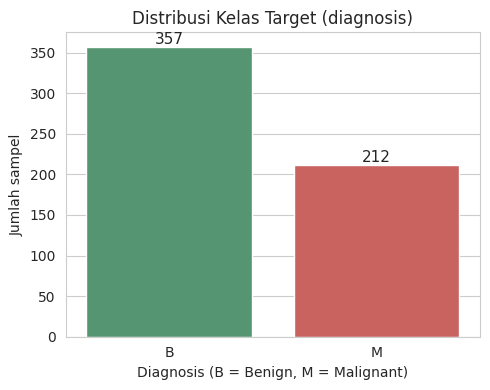

In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

counts = df['diagnosis'].value_counts()
percent = df['diagnosis'].value_counts(normalize=True) * 100
print(pd.DataFrame({'jumlah': counts, 'persen (%)': percent.round(2)}))
print(f"\nRasio kelas B : M = {counts['B'] / counts['M']:.2f} : 1")

plt.figure(figsize=(5, 4))
ax = sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
                 palette=PALETTE, legend=False)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
ax.set_title('Distribusi Kelas Target (diagnosis)')
ax.set_xlabel('Diagnosis (B = Benign, M = Malignant)')
ax.set_ylabel('Jumlah sampel')
plt.tight_layout()
plt.show()

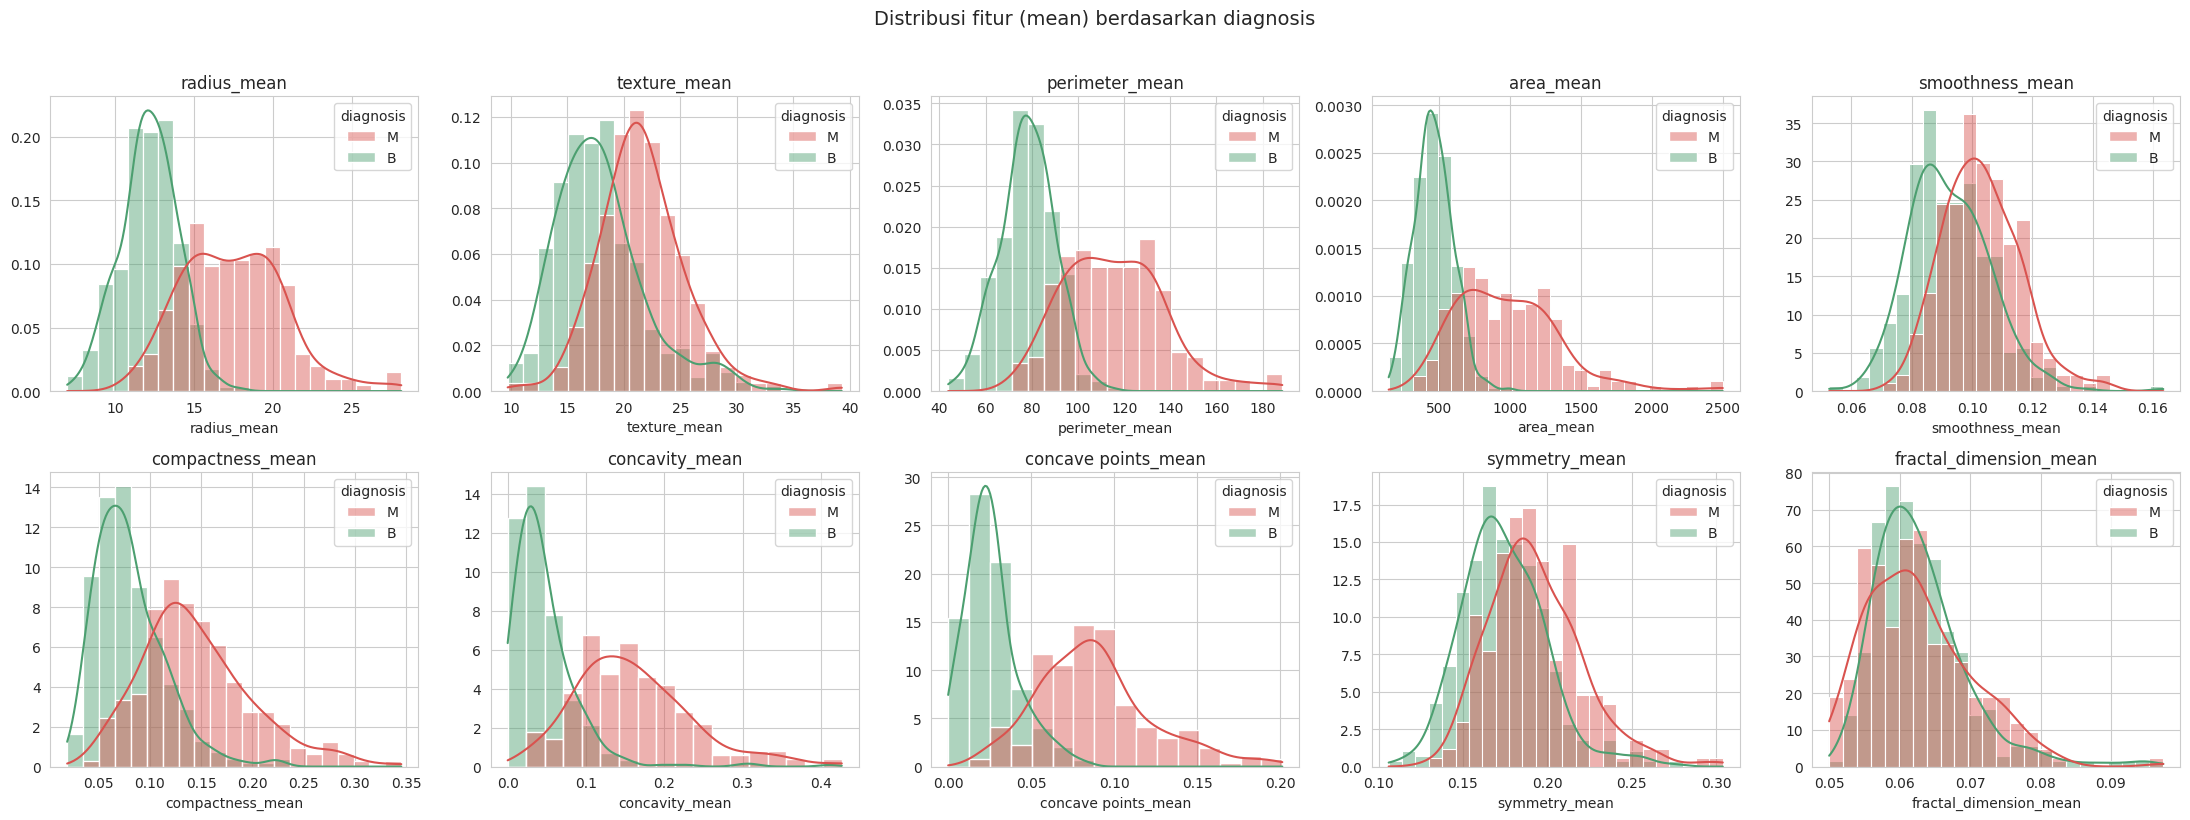

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas (linear) antar kelas, atau justru tumpang tindih.

# Histogram + KDE untuk 10 fitur "mean", dibedakan berdasarkan kelas target
mean_cols = [c for c in df.columns if c.endswith('_mean')]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for ax, col in zip(axes.ravel(), mean_cols):
    sns.histplot(data=df, x=col, hue='diagnosis', kde=True, stat='density',
                 common_norm=False, palette=PALETTE, alpha=0.45, ax=ax)
    ax.set_title(col)
    ax.set_ylabel('')
plt.suptitle('Distribusi fitur (mean) berdasarkan diagnosis', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

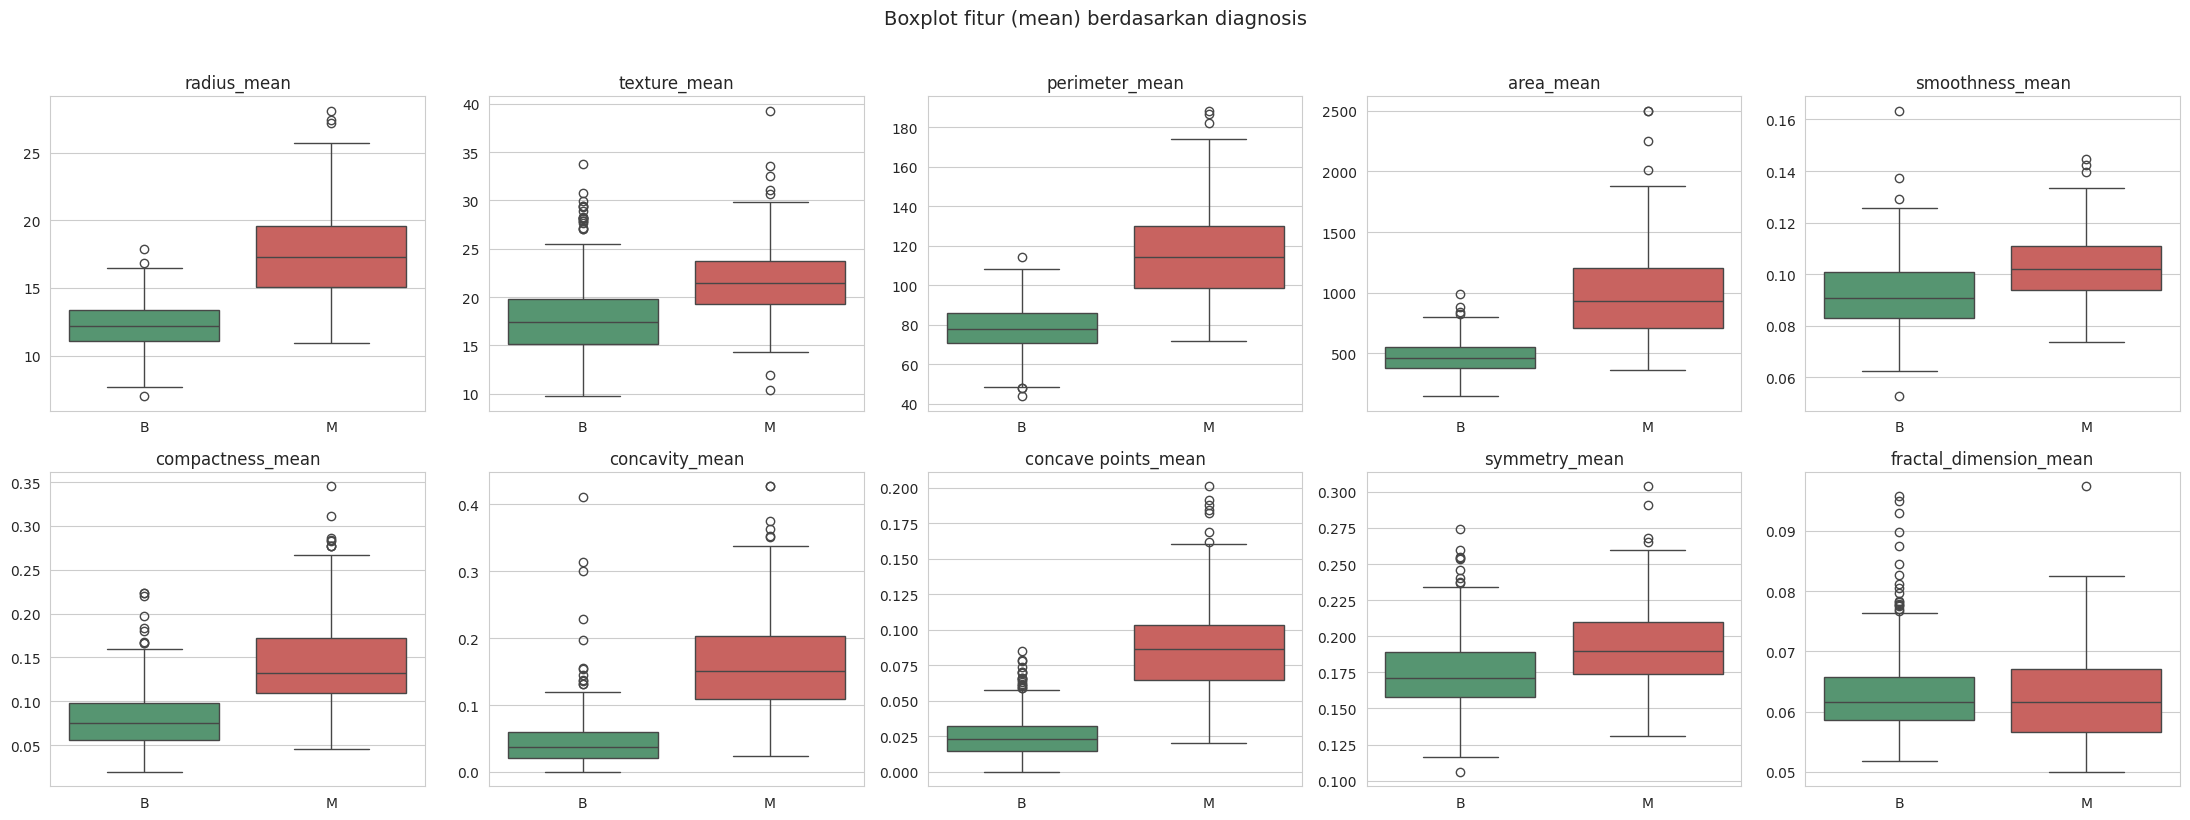

In [5]:
# EDA tambahan 1: boxplot fitur "mean" berdasarkan kelas (melihat pemisahan dan outlier)
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for ax, col in zip(axes.ravel(), mean_cols):
    sns.boxplot(data=df, x='diagnosis', y=col, hue='diagnosis', palette=PALETTE,
                legend=False, order=['B', 'M'], ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('')
plt.suptitle('Boxplot fitur (mean) berdasarkan diagnosis', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

10 fitur dengan korelasi positif tertinggi terhadap kelas Malignant:
concave points_worst    0.794
perimeter_worst         0.783
concave points_mean     0.777
radius_worst            0.776
perimeter_mean          0.743
area_worst              0.734
radius_mean             0.730
area_mean               0.709
concavity_mean          0.696
concavity_worst         0.660
dtype: float64

5 fitur dengan korelasi terendah (paling lemah/negatif):
fractal_dimension_se      0.078
symmetry_se              -0.007
texture_se               -0.008
fractal_dimension_mean   -0.013
smoothness_se            -0.067
dtype: float64


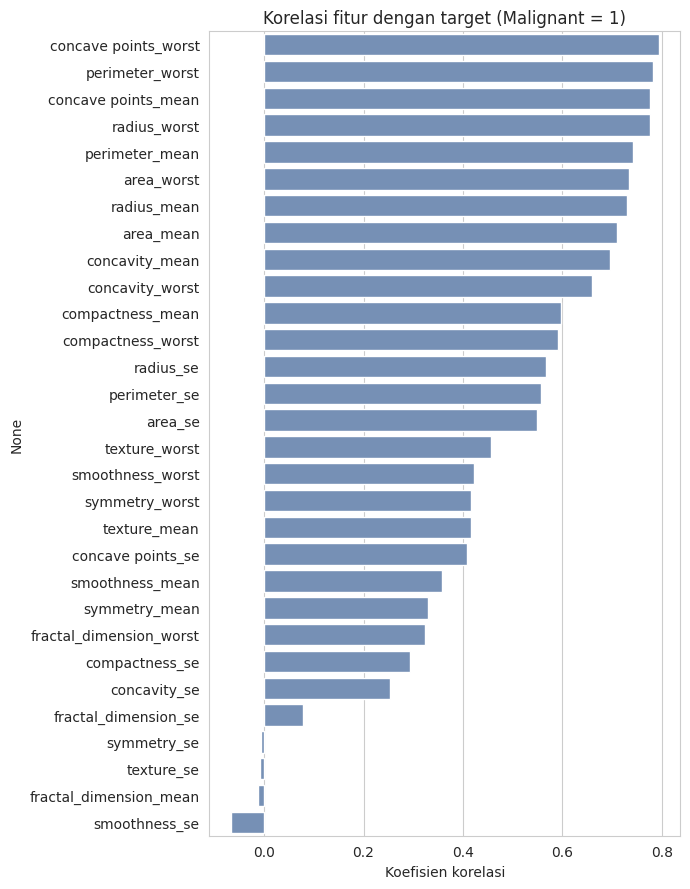

In [6]:
# EDA tambahan 2: fitur mana yang paling berkorelasi dengan target?
# (M = 1, B = 0) -> korelasi Pearson dengan label biner (point-biserial)
feature_cols = [c for c in df.columns if c not in ['id', 'diagnosis', 'Unnamed: 32']]
target_num = (df['diagnosis'] == 'M').astype(int)
corr_target = df[feature_cols].corrwith(target_num).sort_values(ascending=False)

print('10 fitur dengan korelasi positif tertinggi terhadap kelas Malignant:')
print(corr_target.head(10).round(3))
print('\n5 fitur dengan korelasi terendah (paling lemah/negatif):')
print(corr_target.tail(5).round(3))

plt.figure(figsize=(7, 9))
sns.barplot(x=corr_target.values, y=corr_target.index, color='#6C8EBF')
plt.title('Korelasi fitur dengan target (Malignant = 1)')
plt.xlabel('Koefisien korelasi')
plt.tight_layout()
plt.show()

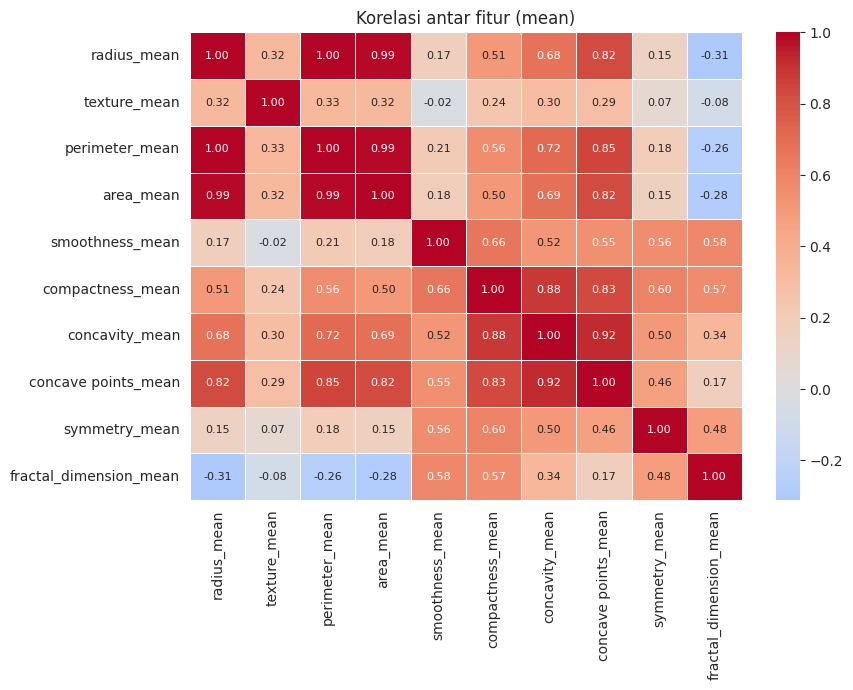


Jumlah pasangan fitur dengan |r| > 0.95 : 15
radius_mean      perimeter_mean     0.998
radius_worst     perimeter_worst    0.994
radius_mean      area_mean          0.987
perimeter_mean   area_mean          0.987
radius_worst     area_worst         0.984
perimeter_worst  area_worst         0.978
radius_se        perimeter_se       0.973
perimeter_mean   perimeter_worst    0.970
dtype: float64


In [7]:
# EDA tambahan 3: heatmap korelasi antar fitur "mean" (multikolinearitas)
plt.figure(figsize=(9, 7))
sns.heatmap(df[mean_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Korelasi antar fitur (mean)')
plt.tight_layout()
plt.show()

# Pasangan fitur dengan korelasi sangat tinggi (|r| > 0.95) di seluruh 30 fitur
corr_mat = df[feature_cols].corr().abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
high_pairs = upper.stack().loc[lambda s: s > 0.95].sort_values(ascending=False)
print(f'\nJumlah pasangan fitur dengan |r| > 0.95 : {len(high_pairs)}')
print(high_pairs.head(8).round(3))

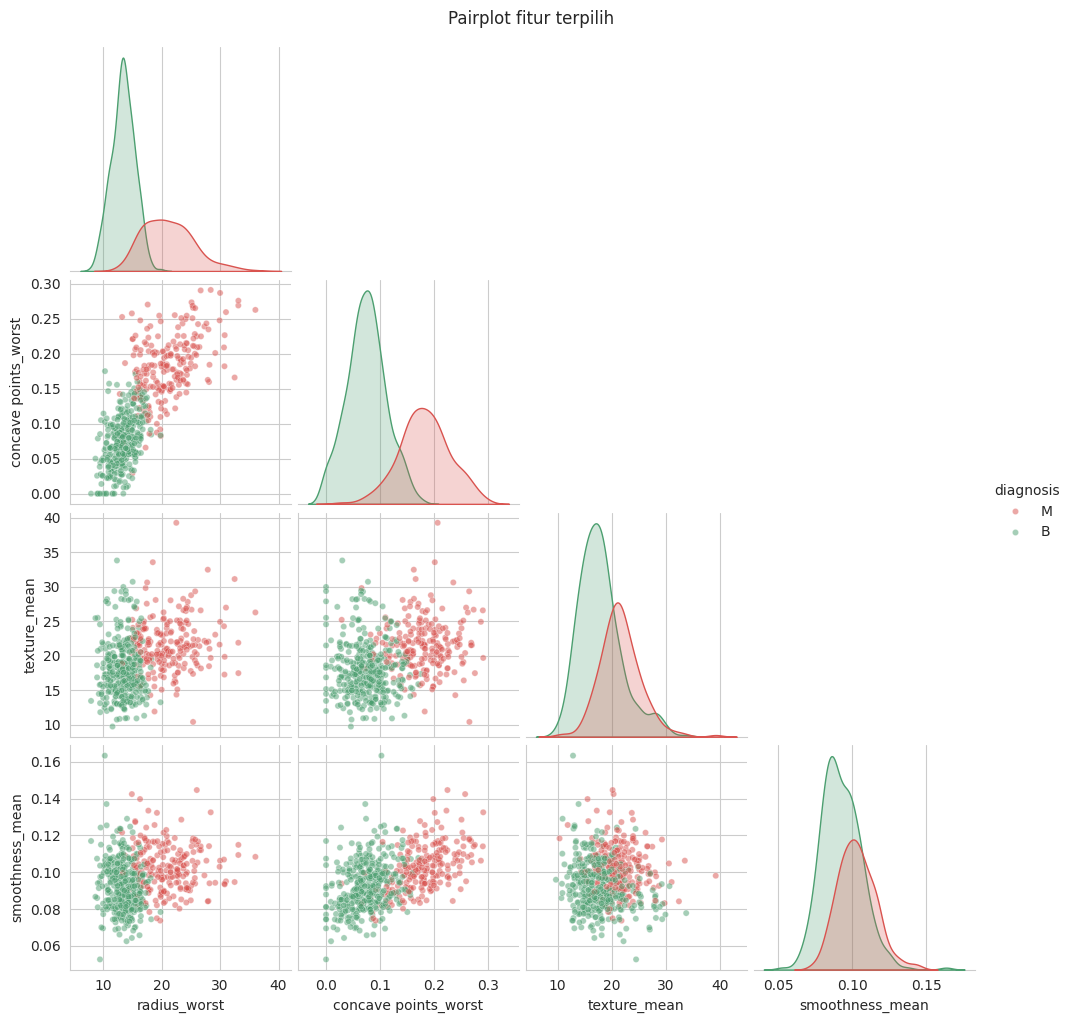

In [8]:
# EDA tambahan 4: pairplot beberapa fitur paling informatif + 1 fitur yang lemah
subset = ['radius_worst', 'concave points_worst', 'texture_mean', 'smoothness_mean']
sns.pairplot(df[subset + ['diagnosis']], hue='diagnosis', palette=PALETTE,
             plot_kws={'alpha': 0.5, 's': 20}, corner=True)
plt.suptitle('Pairplot fitur terpilih', y=1.02)
plt.show()

In [9]:
# EDA tambahan 5: perbedaan skala antar fitur (alasan feature scaling diperlukan)
scale_info = df[feature_cols].agg(['min', 'max', 'std']).T
scale_info['range'] = scale_info['max'] - scale_info['min']
print('Fitur dengan rentang nilai terbesar :')
display(scale_info.sort_values('range', ascending=False).head(4))
print('Fitur dengan rentang nilai terkecil :')
display(scale_info.sort_values('range').head(4))

Fitur dengan rentang nilai terbesar :


,min,max,std,range
area_worst,185.200,4254.0,569.356993,4068.800
area_mean,143.500,2501.0,351.914129,2357.500
area_se,6.802,542.2,45.491006,535.398
perimeter_worst,50.410,251.2,33.602542,200.790


Fitur dengan rentang nilai terkecil :


,min,max,std,range
fractal_dimension_se,0.000895,0.02984,0.002646,0.028945
smoothness_se,0.001713,0.03113,0.003003,0.029417
fractal_dimension_mean,0.049960,0.09744,0.007060,0.047480
concave points_se,0.000000,0.05279,0.006170,0.052790


**Temuan EDA:**
- Dataset memiliki 569 sampel dan 30 fitur numerik; satu-satunya kolom dengan missing value adalah `Unnamed: 32` yang seluruhnya kosong (artefak dari file CSV), sehingga akan dibuang. Kolom `id` hanyalah identitas pasien dan tidak informatif untuk model.
- Distribusi kelas: 357 Benign (62.7%) dan 212 Malignant (37.3%). Rasio sekitar 1.7 : 1, jadi dataset **sedikit imbalanced** tetapi belum parah. Karena itu, selain akurasi, Precision / Recall / F1 pada kelas Malignant tetap perlu dilihat.
- Fitur terkait ukuran dan bentuk sel (`radius`, `perimeter`, `area`, `concavity`, `concave points`) menunjukkan pemisahan yang cukup jelas antara kelas B dan M. Fitur seperti `smoothness`, `symmetry`, dan `fractal_dimension` tumpang tindih banyak.
- Banyak fitur saling berkorelasi sangat tinggi (misalnya `radius`, `perimeter`, `area`), sehingga informasinya redundan (ada 15 pasangan fitur dengan |r| > 0.95). Redundansi ini membuat PCA 2D nanti tetap bisa menangkap sebagian besar struktur data.
- Rentang nilai antar fitur sangat berbeda (`area_worst` mencapai ribuan, sedangkan `fractal_dimension` di kisaran 0.0x), sehingga **feature scaling wajib** dilakukan sebelum SVM.

# 2. Preprocessing

In [10]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

# Kolom 'Unnamed: 32' berisi NaN pada seluruh baris (artefak CSV) -> tidak ada informasi
# yang bisa diimputasi, sehingga strategi yang tepat adalah membuang kolom tersebut.
# Kolom 'id' juga dibuang karena hanya identitas (jika dipakai justru menjadi noise).
# Keduanya adalah operasi pada level kolom (bukan statistik data), sehingga tidak ada data leakage.
df_clean = df.drop(columns=['Unnamed: 32', 'id'])

print('Shape setelah pembersihan :', df_clean.shape)
print('Total missing value       :', df_clean.isnull().sum().sum())
print('Baris duplikat            :', df_clean.duplicated().sum())

# Jika di data lain masih ada missing value pada fitur numerik, imputasi (mis. median) harus
# di-fit hanya pada train set (SimpleImputer di dalam Pipeline) agar tidak terjadi leakage.

Shape setelah pembersihan : (569, 31)
Total missing value       : 0
Baris duplikat            : 0


In [11]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).

# Seluruh fitur sudah bertipe numerik (float64), jadi tidak diperlukan encoding untuk fitur.
# Hanya target 'diagnosis' (B / M) yang bertipe string -> encode menjadi biner:
#   B (Benign / jinak) = 0, M (Malignant / ganas) = 1  -> kelas "positif" adalah Malignant.
print('Tipe data fitur:', df_clean.drop(columns='diagnosis').dtypes.unique())

df_clean['diagnosis'] = df_clean['diagnosis'].map({'B': 0, 'M': 1})
print('\nDistribusi target setelah encoding:')
print(df_clean['diagnosis'].value_counts())

Tipe data fitur: [dtype('float64')]

Distribusi target setelah encoding:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [12]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = df_clean.drop(columns='diagnosis')
y = df_clean['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('\nProporsi kelas Malignant (1):')
print(f'  Seluruh data : {y.mean():.3f}')
print(f'  Train set    : {y_train.mean():.3f}')
print(f'  Test set     : {y_test.mean():.3f}')

X_train: (455, 30) | X_test: (114, 30)

Proporsi kelas Malignant (1):
  Seluruh data : 0.373
  Train set    : 0.374
  Test set     : 0.368


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [13]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit hanya pada train set
X_test_scaled = scaler.transform(X_test)         # test set hanya di-transform

# Verifikasi: train set harus memiliki mean ~0 dan std ~1
print('Mean train set (rata-rata semua fitur) :', X_train_scaled.mean().round(4))
print('Std  train set (rata-rata semua fitur) :', X_train_scaled.std(axis=0).mean().round(4))
print('Mean test set  (rata-rata semua fitur) :', X_test_scaled.mean().round(4),
      '(tidak persis 0, wajar karena memakai statistik train)')

Mean train set (rata-rata semua fitur) : 0.0
Std  train set (rata-rata semua fitur) : 1.0
Mean test set  (rata-rata semua fitur) : -0.024 (tidak persis 0, wajar karena memakai statistik train)


# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [14]:
# Inisialisasi dan latih model SVC dengan kernel='linear' menggunakan train set (yang sudah discaling).

C_VALUE = 1.0   # nilai C yang sama dipakai untuk Linear dan RBF agar perbandingan adil

svm_linear = SVC(kernel='linear', C=C_VALUE, random_state=RANDOM_STATE)
svm_linear.fit(X_train_scaled, y_train)

print('Model Linear berhasil dilatih.')
print(f'Akurasi train : {svm_linear.score(X_train_scaled, y_train):.4f}')

Model Linear berhasil dilatih.
Akurasi train : 0.9890


In [15]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_linear = svm_linear.predict(X_test_scaled)

print('10 prediksi pertama :', y_pred_linear[:10])
print('10 label asli       :', y_test.values[:10])
print(f'Akurasi test (Linear) : {accuracy_score(y_test, y_pred_linear):.4f}')

10 prediksi pertama : [0 1 0 0 0 0 1 0 0 0]
10 label asli       : [0 1 0 1 0 0 1 0 0 0]
Akurasi test (Linear) : 0.9649


## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [16]:
# Inisialisasi dan latih model SVC dengan kernel='rbf' menggunakan train set.
# Gunakan nilai hyperparameter lain (C) yang sama seperti model Linear di atas, agar perbandingan adil.

# gamma='scale' adalah default sklearn: gamma = 1 / (n_fitur * X.var())
svm_rbf = SVC(kernel='rbf', C=C_VALUE, gamma='scale', random_state=RANDOM_STATE)
svm_rbf.fit(X_train_scaled, y_train)

print('Model RBF berhasil dilatih.')
print(f'Nilai gamma (scale) yang dipakai : {svm_rbf._gamma:.5f}')
print(f'Akurasi train : {svm_rbf.score(X_train_scaled, y_train):.4f}')

Model RBF berhasil dilatih.
Nilai gamma (scale) yang dipakai : 0.03333
Akurasi train : 0.9868


In [17]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_rbf = svm_rbf.predict(X_test_scaled)

print('10 prediksi pertama :', y_pred_rbf[:10])
print('10 label asli       :', y_test.values[:10])
print(f'Akurasi test (RBF)  : {accuracy_score(y_test, y_pred_rbf):.4f}')

10 prediksi pertama : [0 1 0 0 0 0 1 0 0 0]
10 label asli       : [0 1 0 1 0 0 1 0 0 0]
Akurasi test (RBF)  : 0.9737


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [18]:
# Latih beberapa model SVC (kernel RBF) dengan variasi nilai C,
# misalnya 0.01, 0.1, 1, 10, 100.
# Gunakan gamma='scale' atau nilai gamma tetap agar perbandingan fokus pada pengaruh C.

C_values = [0.01, 0.1, 1, 10, 100, 1000]

models_C = {}
for C in C_values:
    models_C[C] = SVC(kernel='rbf', C=C, gamma='scale', random_state=RANDOM_STATE)
    models_C[C].fit(X_train_scaled, y_train)

print('Model berhasil dilatih untuk C =', C_values)

Model berhasil dilatih untuk C = [0.01, 0.1, 1, 10, 100, 1000]


In [19]:
# Hitung akurasi pada train set dan test set untuk setiap nilai C yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

results_C = []
for C, model in models_C.items():
    # Cross-validation 5-fold pada train set (scaler ada di dalam pipeline -> tidak bocor antar fold)
    cv_pipe = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=C, gamma='scale'))
    cv_acc = cross_val_score(cv_pipe, X_train, y_train, cv=5, scoring='accuracy').mean()
    results_C.append({
        'C': C,
        'train_acc': model.score(X_train_scaled, y_train),
        'test_acc': model.score(X_test_scaled, y_test),
        'cv_acc (train, 5-fold)': cv_acc,
        'n_support_vectors': model.n_support_.sum(),
    })

results_C = pd.DataFrame(results_C)
results_C['gap (train - test)'] = results_C['train_acc'] - results_C['test_acc']
display(results_C.round(4))

,C,train_acc,test_acc,"cv_acc (train, 5-fold)",n_support_vectors,gap (train - test)
0,0.01,0.6264,0.6316,0.6264,341,-0.0052
1,0.10,0.9538,0.9474,0.9451,202,0.0065
2,1.00,0.9868,0.9737,0.9736,107,0.0131
3,10.00,0.9890,0.9737,0.9736,82,0.0153
4,100.00,1.0000,0.9649,0.9604,70,0.0351
5,1000.00,1.0000,0.9649,0.9604,70,0.0351


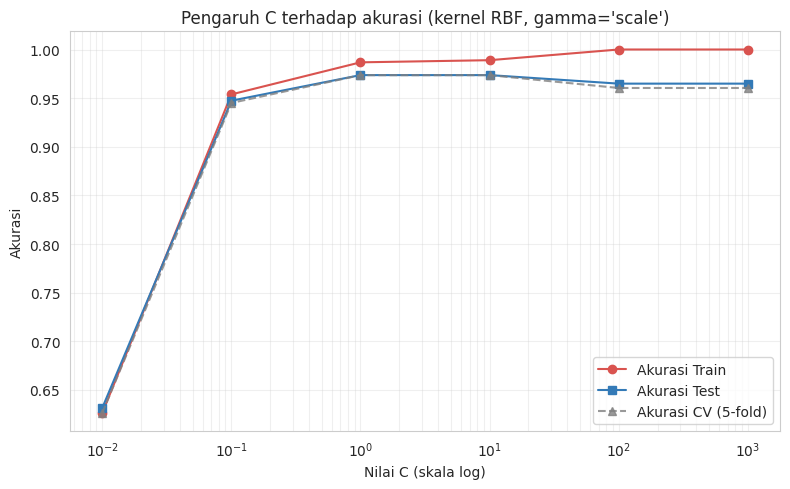

In [20]:
# Plot grafik akurasi training vs testing terhadap nilai C (gunakan sumbu x logaritmik) dalam satu chart.
# Amati pada nilai C berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

plt.figure(figsize=(8, 5))
plt.plot(results_C['C'], results_C['train_acc'], 'o-', label='Akurasi Train', color='#D9534F')
plt.plot(results_C['C'], results_C['test_acc'], 's-', label='Akurasi Test', color='#337AB7')
plt.plot(results_C['C'], results_C['cv_acc (train, 5-fold)'], '^--', label='Akurasi CV (5-fold)',
         color='gray', alpha=0.8)
plt.xscale('log')
plt.xlabel('Nilai C (skala log)')
plt.ylabel('Akurasi')
plt.title("Pengaruh C terhadap akurasi (kernel RBF, gamma='scale')")
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

### Eksperimen Tambahan: Pengaruh Gamma
Pada eksperimen di atas hanya `C` yang divariasikan dengan `gamma='scale'`. Berikut variasi `gamma` dengan `C` tetap (C = 1) untuk melihat pengaruhnya terhadap overfitting/underfitting, dilanjutkan dengan grid kombinasi `C` x `gamma`.

,gamma,train_acc,test_acc,n_support_vectors,gap (train - test)
0,0.0001,0.7846,0.7719,328,0.0127
1,0.0010,0.9495,0.9386,176,0.0109
2,0.0100,0.9758,0.9561,96,0.0197
3,0.1000,0.9890,0.9298,194,0.0592
4,1.0000,1.0000,0.6316,455,0.3684
5,10.0000,1.0000,0.6316,455,0.3684


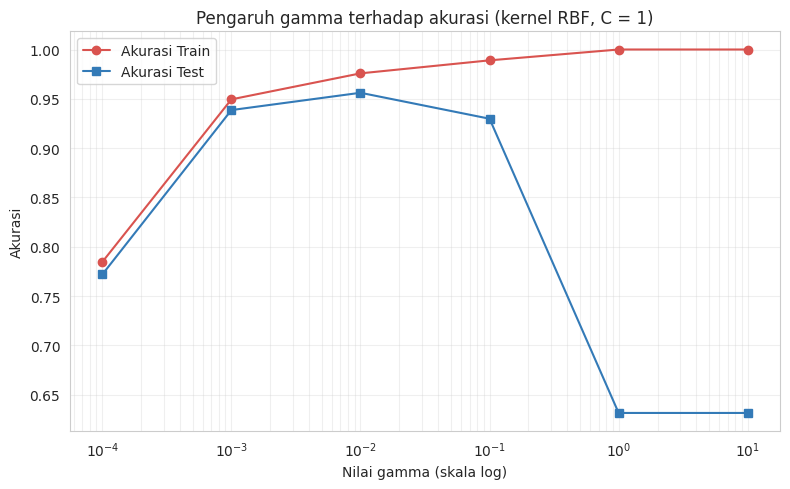

In [21]:
gamma_values = [0.0001, 0.001, 0.01, 0.1, 1, 10]

results_gamma = []
for g in gamma_values:
    m = SVC(kernel='rbf', C=1, gamma=g, random_state=RANDOM_STATE).fit(X_train_scaled, y_train)
    results_gamma.append({
        'gamma': g,
        'train_acc': m.score(X_train_scaled, y_train),
        'test_acc': m.score(X_test_scaled, y_test),
        'n_support_vectors': m.n_support_.sum(),
    })
results_gamma = pd.DataFrame(results_gamma)
results_gamma['gap (train - test)'] = results_gamma['train_acc'] - results_gamma['test_acc']
display(results_gamma.round(4))

plt.figure(figsize=(8, 5))
plt.plot(results_gamma['gamma'], results_gamma['train_acc'], 'o-', label='Akurasi Train', color='#D9534F')
plt.plot(results_gamma['gamma'], results_gamma['test_acc'], 's-', label='Akurasi Test', color='#337AB7')
plt.xscale('log')
plt.xlabel('Nilai gamma (skala log)')
plt.ylabel('Akurasi')
plt.title('Pengaruh gamma terhadap akurasi (kernel RBF, C = 1)')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

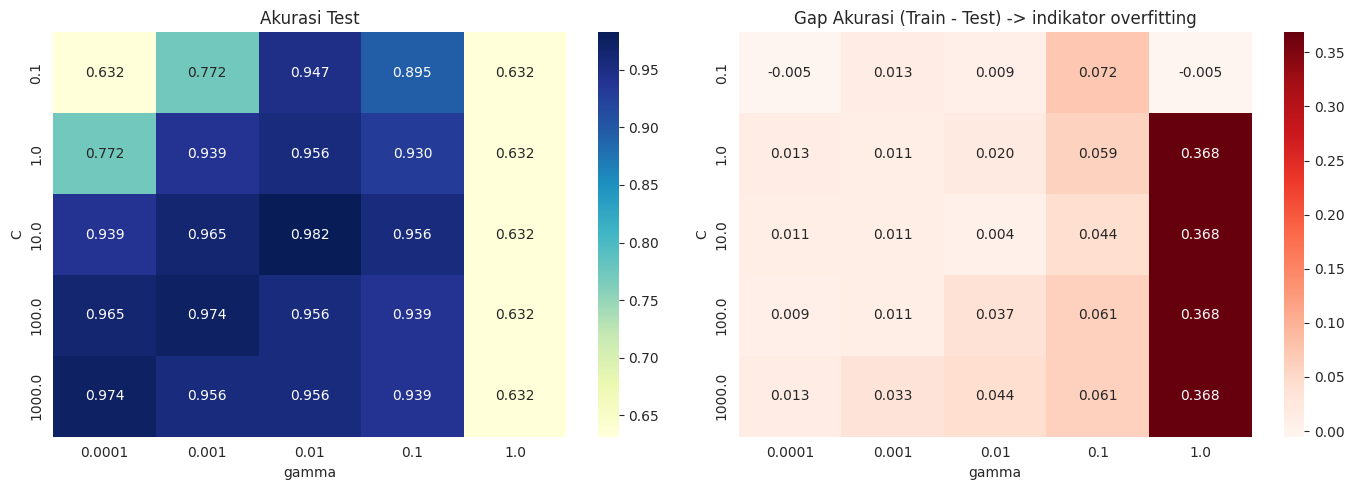

In [22]:
# Grid kombinasi C x gamma : akurasi test dan gap (train - test)
grid_C = [0.1, 1, 10, 100, 1000]
grid_g = [0.0001, 0.001, 0.01, 0.1, 1]

test_grid = pd.DataFrame(index=grid_C, columns=grid_g, dtype=float)
gap_grid = test_grid.copy()
for C in grid_C:
    for g in grid_g:
        m = SVC(kernel='rbf', C=C, gamma=g, random_state=RANDOM_STATE).fit(X_train_scaled, y_train)
        tr, te = m.score(X_train_scaled, y_train), m.score(X_test_scaled, y_test)
        test_grid.loc[C, g] = te
        gap_grid.loc[C, g] = tr - te

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(test_grid, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Akurasi Test')
sns.heatmap(gap_grid, annot=True, fmt='.3f', cmap='Reds', ax=axes[1])
axes[1].set_title('Gap Akurasi (Train - Test) -> indikator overfitting')
for ax in axes:
    ax.set_xlabel('gamma')
    ax.set_ylabel('C')
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [23]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

def get_metrics(y_true, y_pred):
    # Kelas positif = Malignant (1)
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
    }

metrics_df = pd.DataFrame({
    'SVM Linear': get_metrics(y_test, y_pred_linear),
    'SVM RBF': get_metrics(y_test, y_pred_rbf),
}).T
display(metrics_df.round(4))

print('\n=== Classification report: Linear ===')
print(classification_report(y_test, y_pred_linear, target_names=['Benign', 'Malignant']))
print('=== Classification report: RBF ===')
print(classification_report(y_test, y_pred_rbf, target_names=['Benign', 'Malignant']))

,Accuracy,Precision,Recall,F1-Score
SVM Linear,0.9649,1.0,0.9048,0.950
SVM RBF,0.9737,1.0,0.9286,0.963



=== Classification report: Linear ===
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

=== Classification report: RBF ===
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



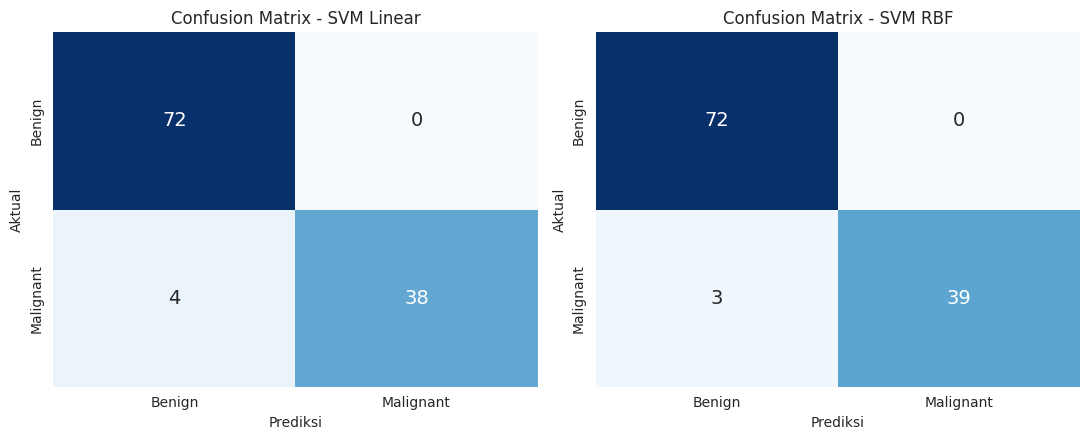

Linear -> TN=72, FP=0, FN=4, TP=38
RBF    -> TN=72, FP=0, FN=3, TP=39


In [24]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, y_pred) in zip(axes, [('SVM Linear', y_pred_linear), ('SVM RBF', y_pred_rbf)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'],
                annot_kws={'size': 14})
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
plt.tight_layout()
plt.show()

for name, y_pred in [('Linear', y_pred_linear), ('RBF', y_pred_rbf)]:
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f'{name:6s} -> TN={tn}, FP={fp}, FN={fn}, TP={tp}')

In [25]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik (atribut model.support_vectors_ atau model.n_support_).
# Bandingkan jumlah support vectors antara model Linear dan RBF.

# Pilih model terbaik berdasarkan F1-Score (jika sama, pilih Recall tertinggi)
best_name = metrics_df.sort_values(['F1-Score', 'Recall'], ascending=False).index[0]
best_model = svm_linear if best_name == 'SVM Linear' else svm_rbf
print('Model dengan performa terbaik :', best_name)

sv_table = pd.DataFrame({
    'SV kelas Benign': [svm_linear.n_support_[0], svm_rbf.n_support_[0]],
    'SV kelas Malignant': [svm_linear.n_support_[1], svm_rbf.n_support_[1]],
    'Total SV': [svm_linear.n_support_.sum(), svm_rbf.n_support_.sum()],
}, index=['SVM Linear', 'SVM RBF'])
sv_table['% dari data train'] = (sv_table['Total SV'] / len(X_train) * 100).round(2)
display(sv_table)

print(f'Bentuk support_vectors_ model terbaik ({best_name}):', best_model.support_vectors_.shape)

Model dengan performa terbaik : SVM RBF


,SV kelas Benign,SV kelas Malignant,Total SV,% dari data train
SVM Linear,19,19,38,8.35
SVM RBF,50,57,107,23.52


Bentuk support_vectors_ model terbaik (SVM RBF): (107, 30)


Varians yang dijelaskan PC1 + PC2 : 0.6314


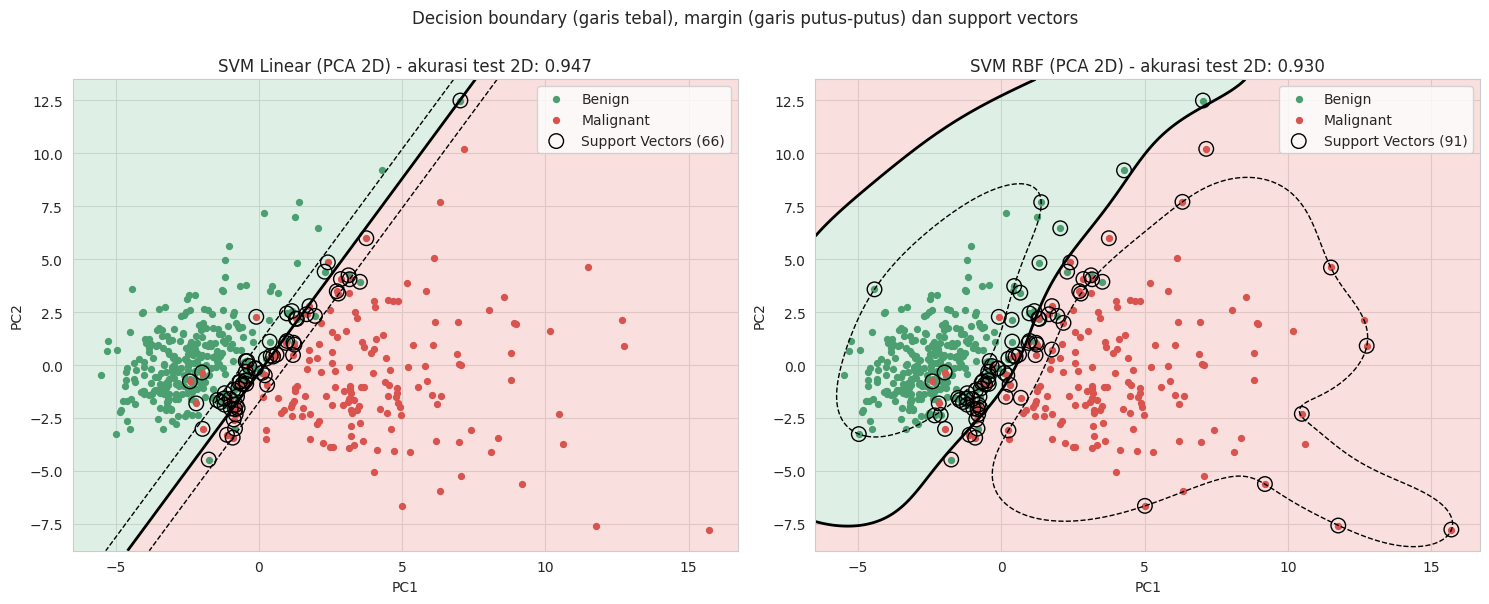

In [26]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.

# Reduksi dimensi 30 fitur -> 2 komponen utama (PCA di-fit hanya pada train set)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d = pca.transform(X_test_scaled)
print('Varians yang dijelaskan PC1 + PC2 :', pca.explained_variance_ratio_.sum().round(4))

# Model "visualisasi": hyperparameter sama, dilatih ulang pada data 2D
svm_linear_2d = SVC(kernel='linear', C=C_VALUE).fit(X_train_2d, y_train)
svm_rbf_2d = SVC(kernel='rbf', C=C_VALUE, gamma='scale').fit(X_train_2d, y_train)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (name, m) in zip(axes, [('SVM Linear', svm_linear_2d), ('SVM RBF', svm_rbf_2d)]):
    Z = m.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[Z.min(), 0, Z.max()], colors=['#BFE3CC', '#F4C2C0'], alpha=0.5)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'], linewidths=[1, 2, 1])
    ax.scatter(X_train_2d[y_train == 0, 0], X_train_2d[y_train == 0, 1], c='#4C9F70', s=18, label='Benign')
    ax.scatter(X_train_2d[y_train == 1, 0], X_train_2d[y_train == 1, 1], c='#D9534F', s=18, label='Malignant')
    ax.scatter(m.support_vectors_[:, 0], m.support_vectors_[:, 1], s=110, facecolors='none',
               edgecolors='k', linewidths=1, label=f'Support Vectors ({len(m.support_vectors_)})')
    acc_2d = m.score(X_test_2d, y_test)
    ax.set_title(f'{name} (PCA 2D) - akurasi test 2D: {acc_2d:.3f}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(loc='upper right')
plt.suptitle('Decision boundary (garis tebal), margin (garis putus-putus) dan support vectors', y=1.0)
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa SVM dengan kernel Linear vs RBF. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian, dikaitkan dengan bentuk sebaran data pada EDA?
- Jelaskan temuan dari eksperimen regularisasi (nilai `C`). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Bandingkan jumlah support vectors antara model Linear dan RBF. Apa hubungan jumlah support vectors dengan kompleksitas batas keputusan yang terbentuk?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

## Hasil Analisis

Seluruh angka di bawah ini berasal dari eksperimen pada notebook ini (dataset Breast Cancer Wisconsin, 569 sampel, 30 fitur, split 80:20 stratified, `random_state=42`, kelas positif = Malignant).

### 1. Perbandingan Kernel Linear vs RBF

| Model | Accuracy | Precision | Recall | F1-Score | FP | FN |
|-------|----------|-----------|--------|----------|----|----|
| SVM Linear (C=1) | 0.9649 | 1.0000 | 0.9048 | 0.9500 | 0 | 4 |
| SVM RBF (C=1, gamma='scale') | 0.9737 | 1.0000 | 0.9286 | 0.9630 | 0 | 3 |

- RBF sedikit lebih unggul, tetapi selisihnya **hanya 1 sampel** (FN 4 menjadi 3 dari 114 data uji, atau sekitar 0.9% akurasi). Dengan test set sekecil ini, selisih tersebut **belum bisa dianggap perbedaan yang signifikan**. Hasil 5-fold CV pada train set untuk RBF (C=1) adalah 0.9736, tidak jauh dari akurasi test, yang menunjukkan performanya stabil.
- **Mengapa keduanya hampir sama?** Dari EDA, fitur-fitur utama seperti `concave points`, `perimeter`, `radius`, `area`, dan `concavity` (korelasi dengan target 0.70 hingga 0.79) memisahkan kelas Benign dan Malignant dengan cukup jelas: distribusi Malignant bergeser ke nilai yang lebih besar. Pada ruang 30 dimensi, data ini sudah hampir terpisah secara linear, sehingga hyperplane lurus sudah cukup baik dan tambahan fleksibilitas RBF hanya memberi keuntungan kecil. Pada visualisasi PCA 2D pun, batas kedua kelas terlihat seperti garis lurus dengan sedikit tumpang tindih di sekitar perbatasan, dan model Linear 2D (akurasi test 0.947) bahkan sedikit lebih baik daripada RBF 2D (0.930) karena batas RBF yang melengkung ikut menyesuaikan beberapa titik di area tumpang tindih. Perlu diingat model 2D ini hanya untuk visualisasi, bukan model utama.
- **Kesalahan kedua model adalah Precision = 1.0 dan semua error berupa False Negative**, yaitu kasus Malignant yang diprediksi Benign. Dalam konteks diagnosis kanker, ini jenis kesalahan yang paling berbahaya, sehingga Recall pada kelas Malignant (0.90 untuk Linear dan 0.93 untuk RBF) adalah metrik yang paling perlu diperhatikan, bukan hanya akurasi.

### 2. Eksperimen Regularisasi (C dan Gamma)

**Pengaruh C (kernel RBF, gamma='scale'):**

| C | Train Acc | Test Acc | CV Acc | Gap | Jumlah SV |
|---|-----------|----------|--------|-----|-----------|
| 0.01 | 0.6264 | 0.6316 | 0.6264 | -0.005 | 341 |
| 0.1 | 0.9538 | 0.9474 | 0.9451 | 0.007 | 202 |
| 1 | 0.9868 | 0.9737 | 0.9736 | 0.013 | 107 |
| 10 | 0.9890 | 0.9737 | 0.9736 | 0.015 | 82 |
| 100 | 1.0000 | 0.9649 | 0.9604 | 0.035 | 70 |
| 1000 | 1.0000 | 0.9649 | 0.9604 | 0.035 | 70 |

- **Underfitting pada C kecil.** Pada C = 0.01, akurasi train dan test sama-sama rendah (sekitar 0.63). Angka ini sama dengan proporsi kelas mayoritas (Benign), artinya model praktis memprediksi semua data sebagai Benign. Regularisasi terlalu kuat sehingga margin terlalu lebar dan hampir semua titik (341 dari 455) menjadi support vector.
- **Zona terbaik pada C = 1 sampai 10.** Akurasi test dan CV tertinggi (0.9737) dengan gap train-test yang kecil (0.013 sampai 0.015).
- **Gejala overfitting mulai terlihat pada C = 100.** Akurasi train naik menjadi 1.0 (model menghafal seluruh data train), sementara akurasi test turun menjadi 0.9649 dan CV turun menjadi 0.9604. Ciri-cirinya pada grafik: **kurva train terus naik dan menempel di 1.0, sedangkan kurva test dan CV mendatar lalu turun sedikit, sehingga jarak antar kurva melebar** (gap 0.015 menjadi 0.035). Hasil C = 1000 identik dengan C = 100 karena data train sudah terpisah sempurna sehingga C yang lebih besar tidak mengubah solusi lagi. Overfitting di sini tergolong ringan karena `gamma='scale'` sudah cukup moderat.

**Pengaruh gamma (C = 1):**

| gamma | Train Acc | Test Acc | Jumlah SV |
|-------|-----------|----------|-----------|
| 0.0001 | 0.7846 | 0.7719 | 328 |
| 0.001 | 0.9495 | 0.9386 | 176 |
| 0.01 | 0.9758 | 0.9561 | 96 |
| 0.1 | 0.9890 | 0.9298 | 194 |
| 1 | 1.0000 | 0.6316 | 455 |
| 10 | 1.0000 | 0.6316 | 455 |

- Gamma terlalu kecil (0.0001) menyebabkan **underfitting** karena pengaruh tiap titik terlalu luas sehingga batas keputusan menjadi hampir linear dan terlalu kaku.
- Gamma terlalu besar menyebabkan **overfitting yang jauh lebih parah** dibanding C besar. Pada gamma = 0.1 gap sudah 0.059, dan pada gamma >= 1 akurasi train 1.0 tetapi akurasi test jatuh ke 0.6316 dengan **seluruh 455 titik train menjadi support vector**. Setiap titik hanya mempengaruhi area di sekitarnya sendiri, sehingga model sekadar menghafal data.
- Pada heatmap grid C x gamma terlihat bahwa kombinasi terbaik berada di pola diagonal: **gamma kecil membutuhkan C besar, dan gamma besar membutuhkan C kecil**, karena keduanya sama-sama mengatur kompleksitas model. Akurasi test tertinggi pada grid adalah 0.982 (C = 10, gamma = 0.01). Angka ini hanya observasi, karena kombinasi tersebut dipilih dengan melihat test set. Untuk pemilihan hyperparameter yang sah, gunakan cross-validation pada train set (misalnya `GridSearchCV`).

### 3. Jumlah Support Vectors

| Model | SV Benign | SV Malignant | Total SV | % dari data train |
|-------|-----------|--------------|----------|-------------------|
| SVM Linear | 19 | 19 | 38 | 8.35% |
| SVM RBF | 50 | 57 | 107 | 23.52% |

- Model RBF membutuhkan sekitar **2.8 kali lebih banyak support vector** dibanding Linear (107 vs 38). Pada visualisasi PCA 2D pola yang sama terlihat (66 SV untuk Linear vs 91 SV untuk RBF).
- **Hubungannya dengan kompleksitas batas keputusan:** batas Linear berupa satu hyperplane datar yang cukup ditentukan oleh sedikit titik di dekat perbatasan. Batas RBF adalah gabungan fungsi kernel di sekitar setiap support vector, sehingga bentuknya melengkung dan fleksibel, dan butuh lebih banyak titik acuan untuk menopangnya. Pada plot PCA 2D terlihat batas RBF yang berkelok dan margin berbentuk "pulau" yang mengelilingi kelas.
- Jumlah SV juga bisa dibaca sebagai indikator kompleksitas dan risiko overfitting: pada eksperimen gamma, ketika SV mendekati seluruh data train (455), model sudah menghafal dan akurasi test ambruk. Sebaliknya, SV yang sedikit relatif terhadap jumlah data umumnya berarti model sederhana dan generalisasinya baik. Namun perlu hati-hati: pada eksperimen C, jumlah SV justru **menurun** saat C membesar (341 menjadi 70) karena margin menyempit dan lebih sedikit titik yang berada di dalam margin. Jadi jumlah SV dipengaruhi oleh C (lebar margin) sekaligus gamma (kelenturan batas), dan tidak bisa dibaca sendirian.

### Catatan Keterbatasan
Evaluasi memakai satu kali split dengan 114 data uji, sehingga 1 sampel setara 0.88% akurasi. Perbedaan kecil antar model (misalnya Linear vs RBF) sebaiknya dikonfirmasi dengan cross-validation berulang sebelum disimpulkan.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba kernel Polynomial, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

## Kesimpulan

1. **Kedua kernel bekerja sangat baik pada dataset ini.** SVM Linear mencapai akurasi 96.49% dan SVM RBF 97.37% pada data uji. Keduanya memiliki Precision 1.0 (tidak ada False Positive), namun masih ada False Negative (4 untuk Linear dan 3 untuk RBF). Selisih keduanya hanya 1 sampel sehingga tidak signifikan secara statistik. Hal ini sejalan dengan hasil EDA bahwa banyak fitur (`concave points`, `perimeter`, `radius`, `area`) sudah memisahkan kedua kelas dengan jelas, sehingga data hampir terpisah secara linear.
2. **Feature scaling terbukti diperlukan.** Rentang fitur sangat berbeda (`area_worst` hingga 4254, sedangkan `fractal_dimension` hanya sekitar 0.0x). Scaler hanya di-fit pada train set untuk menghindari data leakage.
3. **Parameter C mengatur trade-off underfitting dan overfitting.** C = 0.01 menyebabkan underfitting (model memprediksi hampir semuanya sebagai Benign, akurasi sekitar 63%), C = 1 sampai 10 memberi performa terbaik dan paling seimbang (test 97.37%), sedangkan C >= 100 mulai overfitting (train 100%, test dan CV turun, gap 3.5%).
4. **Gamma berpengaruh lebih drastis daripada C.** Gamma sangat kecil menyebabkan underfitting, sedangkan gamma >= 1 menyebabkan overfitting ekstrem (train 100%, test hanya 63.2%, seluruh data train menjadi support vector). C dan gamma saling berkaitan sehingga sebaiknya dituning bersama.
5. **Jumlah support vector mencerminkan kompleksitas model.** Linear hanya memerlukan 38 SV (8.4% data train), sedangkan RBF memerlukan 107 SV (23.5%), sejalan dengan batas keputusan RBF yang lebih fleksibel.
6. **Pilihan model:** karena performa keduanya setara, model Linear dapat dipilih karena lebih sederhana, lebih cepat, dan lebih mudah diinterpretasikan. Model RBF dipilih bila ingin Recall pada kelas Malignant sedikit lebih tinggi (0.93 vs 0.90), dengan syarat hyperparameter dituning dengan benar.

## Saran

- Lakukan **hyperparameter tuning** dengan `GridSearchCV` atau `RandomizedSearchCV` (stratified k-fold pada train set) untuk C dan gamma, bukan memilih berdasarkan test set.
- Gunakan **repeated stratified cross-validation** untuk membandingkan Linear vs RBF secara lebih andal, karena test set hanya 114 sampel.
- Karena kasus medis lebih menuntut **Recall kelas Malignant** yang tinggi, coba `class_weight='balanced'` dan/atau atur threshold keputusan (`decision_function`) untuk menekan False Negative, serta evaluasi dengan ROC-AUC dan Precision-Recall curve.
- Coba kernel **Polynomial** atau **Sigmoid**, serta bandingkan dengan model lain (Logistic Regression, Random Forest, Gradient Boosting) sebagai pembanding.
- Banyak fitur yang saling berkorelasi tinggi (15 pasangan dengan |r| > 0.95), sehingga **feature selection atau PCA** berpotensi menyederhanakan model tanpa menurunkan performa.
- Kondisi data sedikit imbalanced (63% Benign vs 37% Malignant); teknik seperti SMOTE atau class weighting dapat dicoba jika Recall perlu ditingkatkan.